In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle
# 원핫인코더
from sklearn.preprocessing import OneHotEncoder

In [2]:
!apt-get -qq -y install fonts-nanum

Selecting previously unselected package fonts-nanum.
(Reading database ... 126281 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
# 런타임에 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 프로젝트 셋팅

In [5]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = '/content/drive/MyDrive/model/best_model3_ab.dat'
# 교차검증 횟수
cv_count = 10
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

### 데이터 준비
- 데이터를 읽어오고 필요한 전처리까지 다 한다음 입력데이터는 train_X, 결과데이터는 train_y라는 변수에 담아서 준비해주세요

In [6]:
# 데이터 준비.
# AB와 CDE데이터를 따로 모델링을 해줘야한다
# 그러므로 AB와 CDE의 Train데이터를 따로 준비해야한다.
# Train 말고 Test는 동시에 존재하지만 이것 역시 따로 학습시켜야하니 AB데이터의컬럼, CDE데이터의 컬럼별로 분리시켜준다.
# target 데이터의 경우 AB와 CDE에 Segment가 있는데 이걸 AB만 떼서 준비한다.

ab_train_df = pd.read_parquet('/content/drive/MyDrive/abcde/ab_train29.parquet')

test_df = pd.read_parquet('/content/drive/MyDrive/abcde/ab_cde_test44.parquet')
# test_df를 ab_train_df와 cd_train_df 각각의 컬럼에 맞춰 두개로 나눈다.

# AB 분리
ab_cols = ab_train_df.columns

# 'Segment'컬럼은 타겟이라서 test_df에 없어도 됨
missing_ab_cols = [col for col in ab_cols if col != 'Segment' and col not in test_df.columns]

if missing_ab_cols:
    print(f"Warning: test_df에 ab_cols 중 누락된 컬럼이 있습니다: {missing_ab_cols}")

# ab_test_df, cd_test_df 생성
ab_test_df = test_df[ab_cols.drop('Segment')]

# target 데이터의 경우 AB와 CDE에 Segment가 있는데 이걸 각각 떼서 준비한다.
ab_target_df = ab_train_df[['ID','기준년월','Segment']]

In [7]:
ab_test_df

,ID,기준년월,이용후경과월_할부_무이자,이용후경과월_할부,이용개월수_할부_무이자_R12M,이용개월수_할부_R12M,카드이용한도금액_B2M,카드이용한도금액_B1M,카드이용한도금액,이용개월수_할부_R6M,...,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,대표청구서수령지구분코드,청구서수령방법,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,TEST_00000,201807,12,12,0,0,50006,49999,50902,0,...,자녀성장(1),1회 이상,1회 이상,1회 이상,이메일,이메일,1일 이상,1회 이상,1회 이상,1회 이상
1,TEST_00001,201807,0,0,9,10,50003,50000,50080,6,...,자녀독립기,1회 이상,5회 이상,1회 이상,당사페이앱+이메일,문자메세지,5일 이상,1회 이상,1회 이상,1회 이상
2,TEST_00002,201807,3,1,5,7,100056,100053,100045,3,...,자녀성장(1),1회 이상,10회 이상,1회 이상,이메일,이메일,10일 이상,1회 이상,1회 이상,1회 이상
3,TEST_00003,201807,2,2,1,2,19693,21035,18508,1,...,자녀성장(1),1회 이상,15회 이상,1회 이상,우편,우편,15일 이상,1회 이상,1회 이상,1회 이상
4,TEST_00004,201807,0,0,6,7,3924,4291,4033,4,...,자녀성장(1),1회 이상,1회 이상,1회 이상,우편,우편,1일 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,TEST_99995,201812,12,12,0,0,0,0,0,0,...,노년생활,1회 이상,1회 이상,1회 이상,우편,우편,1일 이상,1회 이상,1회 이상,1회 이상
599996,TEST_99996,201812,12,12,0,0,49990,50008,49025,0,...,자녀출산기,1회 이상,1회 이상,1회 이상,우편,우편,1일 이상,1회 이상,1회 이상,1회 이상
599997,TEST_99997,201812,12,12,0,0,30004,30011,29996,0,...,자녀성장(1),1회 이상,1회 이상,1회 이상,이메일,이메일,1일 이상,1회 이상,1회 이상,1회 이상
599998,TEST_99998,201812,2,2,3,3,37139,37999,42610,1,...,가족구축기,1회 이상,5회 이상,1회 이상,K톡명세서+이메일,K톡,5일 이상,1회 이상,1회 이상,1회 이상


In [8]:
# 데이터 프레임을 합친다.
all_df = pd.concat([ab_train_df, ab_test_df])
all_df.reset_index(inplace=True, drop=True)
all_df

,ID,기준년월,Segment,이용후경과월_할부_무이자,이용후경과월_할부,이용개월수_할부_무이자_R12M,이용개월수_할부_R12M,카드이용한도금액_B2M,카드이용한도금액_B1M,카드이용한도금액,...,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,대표청구서수령지구분코드,청구서수령방법,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,TRAIN_002898,201807,A,0,0,9,10,224182,206178,207389,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
1,TRAIN_002898,201808,A,0,0,9,11,206178,207915,212983,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
2,TRAIN_002898,201809,A,0,0,9,11,207915,212331,217163,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
3,TRAIN_002898,201810,A,0,0,9,11,212331,225457,205333,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
4,TRAIN_002898,201811,A,0,0,9,11,225457,217014,215143,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601111,TEST_99995,201812,NaN,12,12,0,0,0,0,0,...,노년생활,1회 이상,1회 이상,1회 이상,우편,우편,1일 이상,1회 이상,1회 이상,1회 이상
601112,TEST_99996,201812,NaN,12,12,0,0,49990,50008,49025,...,자녀출산기,1회 이상,1회 이상,1회 이상,우편,우편,1일 이상,1회 이상,1회 이상,1회 이상
601113,TEST_99997,201812,NaN,12,12,0,0,30004,30011,29996,...,자녀성장(1),1회 이상,1회 이상,1회 이상,이메일,이메일,1일 이상,1회 이상,1회 이상,1회 이상
601114,TEST_99998,201812,NaN,2,2,3,3,37139,37999,42610,...,가족구축기,1회 이상,5회 이상,1회 이상,K톡명세서+이메일,K톡,5일 이상,1회 이상,1회 이상,1회 이상


In [9]:
# 결과 데이터는 제거한다.
all_df.drop('Segment', axis=1, inplace=True)
all_df

,ID,기준년월,이용후경과월_할부_무이자,이용후경과월_할부,이용개월수_할부_무이자_R12M,이용개월수_할부_R12M,카드이용한도금액_B2M,카드이용한도금액_B1M,카드이용한도금액,이용개월수_할부_R6M,...,Life_Stage,인입횟수_ARS_R6M,캠페인접촉건수_R12M,이용메뉴건수_ARS_R6M,대표청구서수령지구분코드,청구서수령방법,캠페인접촉일수_R12M,방문일수_PC_R6M,방문횟수_PC_R6M,할인건수_R3M
0,TRAIN_002898,201807,0,0,9,10,224182,206178,207389,6,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
1,TRAIN_002898,201808,0,0,9,11,206178,207915,212983,6,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
2,TRAIN_002898,201809,0,0,9,11,207915,212331,217163,6,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
3,TRAIN_002898,201810,0,0,9,11,212331,225457,205333,6,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
4,TRAIN_002898,201811,0,0,9,11,225457,217014,215143,6,...,자녀성장(1),10회 이상,5회 이상,10회 이상,우편,우편,5일 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
601111,TEST_99995,201812,12,12,0,0,0,0,0,0,...,노년생활,1회 이상,1회 이상,1회 이상,우편,우편,1일 이상,1회 이상,1회 이상,1회 이상
601112,TEST_99996,201812,12,12,0,0,49990,50008,49025,0,...,자녀출산기,1회 이상,1회 이상,1회 이상,우편,우편,1일 이상,1회 이상,1회 이상,1회 이상
601113,TEST_99997,201812,12,12,0,0,30004,30011,29996,0,...,자녀성장(1),1회 이상,1회 이상,1회 이상,이메일,이메일,1일 이상,1회 이상,1회 이상,1회 이상
601114,TEST_99998,201812,2,2,3,3,37139,37999,42610,1,...,가족구축기,1회 이상,5회 이상,1회 이상,K톡명세서+이메일,K톡,5일 이상,1회 이상,1회 이상,1회 이상


In [10]:
# all_df에서 ID와 기준년월 컬럼도 제거해둔다. 두 컬럼은 따로 저장해둔다
id_df = all_df['ID']
y_df = all_df['기준년월']
all_df.drop(['ID', '기준년월'], axis=1, inplace=True)

In [11]:
ab_encoder = LabelEncoder()

# 범주형 컬럼 각각 인코더
인입횟수_ARS_R6M인코더 = LabelEncoder()
방문횟수_앱_R6M인코더 = LabelEncoder()
방문횟수_PC_R6M인코더 = LabelEncoder()
방문일수_PC_R6M인코더 = LabelEncoder()
거주시도명인코더 = LabelEncoder()
RV전환가능여부인코더 = LabelEncoder()
연령인코더 = LabelEncoder()
Life_Stage인코더 = LabelEncoder()
캠페인접촉건수_R12M인코더 = LabelEncoder()
이용메뉴건수_ARS_R6M인코더 = LabelEncoder()
대표청구서수령지구분코드인코더 = LabelEncoder()
청구서수령방법인코더 = LabelEncoder()
캠페인접촉일수_R12M인코더 = LabelEncoder()
할인건수_R3M인코더 = LabelEncoder()

# ab 범주형 인코딩
방문횟수_앱_R6M인코더.fit(all_df['방문횟수_앱_R6M'].astype(str))
거주시도명인코더.fit(all_df['거주시도명'])
RV전환가능여부인코더.fit(all_df['RV전환가능여부'])
연령인코더.fit(all_df['연령'])
Life_Stage인코더.fit(all_df['Life_Stage'])
인입횟수_ARS_R6M인코더.fit(all_df['인입횟수_ARS_R6M'])
캠페인접촉건수_R12M인코더.fit(all_df['캠페인접촉건수_R12M'])
이용메뉴건수_ARS_R6M인코더.fit(all_df['이용메뉴건수_ARS_R6M'])
대표청구서수령지구분코드인코더.fit(all_df['대표청구서수령지구분코드'])
청구서수령방법인코더.fit(all_df['청구서수령방법'])
캠페인접촉일수_R12M인코더.fit(all_df['캠페인접촉일수_R12M'])
방문일수_PC_R6M인코더.fit(all_df['방문일수_PC_R6M'])
방문횟수_PC_R6M인코더.fit(all_df['방문횟수_PC_R6M'])
할인건수_R3M인코더.fit(all_df['할인건수_R3M'])


LabelEncoder()

In [12]:
all_df['방문횟수_앱_R6M'].value_counts()

,count
방문횟수_앱_R6M,
1회 이상,522137
10회 이상,23862
20회 이상,15460
30회 이상,13328
40회 이상,11154
50회 이상,7692
60회 이상,5367
70회 이상,2042
80회 이상,74


In [13]:
# ab_test도 위 ab범주형인코더를 이용해서변환한다.
all_df['방문횟수_앱_R6M'] = 방문횟수_앱_R6M인코더.transform(all_df['방문횟수_앱_R6M'].astype(str))
all_df['거주시도명'] = 거주시도명인코더.transform(all_df['거주시도명'])
all_df['RV전환가능여부'] = RV전환가능여부인코더.transform(all_df['RV전환가능여부'])
all_df['연령'] = 연령인코더.transform(all_df['연령'])
all_df['Life_Stage'] = Life_Stage인코더.transform(all_df['Life_Stage'])
all_df['인입횟수_ARS_R6M'] = 인입횟수_ARS_R6M인코더.transform(all_df['인입횟수_ARS_R6M'])
all_df['캠페인접촉건수_R12M'] = 캠페인접촉건수_R12M인코더.transform(all_df['캠페인접촉건수_R12M'])
all_df['이용메뉴건수_ARS_R6M'] = 이용메뉴건수_ARS_R6M인코더.transform(all_df['이용메뉴건수_ARS_R6M'])
all_df['대표청구서수령지구분코드'] = 대표청구서수령지구분코드인코더.transform(all_df['대표청구서수령지구분코드'])
all_df['청구서수령방법'] = 청구서수령방법인코더.transform(all_df['청구서수령방법'])
all_df['캠페인접촉일수_R12M'] = 캠페인접촉일수_R12M인코더.transform(all_df['캠페인접촉일수_R12M'])
all_df['방문일수_PC_R6M'] = 방문일수_PC_R6M인코더.transform(all_df['방문일수_PC_R6M'])
all_df['방문횟수_PC_R6M'] = 방문횟수_PC_R6M인코더.transform(all_df['방문횟수_PC_R6M'])
all_df['할인건수_R3M'] = 할인건수_R3M인코더.transform(all_df['할인건수_R3M'])

# Scaler 학습
scalerX = StandardScaler()
scalerX.fit(all_df)

StandardScaler()

In [14]:
all_df['방문횟수_앱_R6M'].value_counts()

,count
방문횟수_앱_R6M,
1,522137
0,23862
2,15460
3,13328
4,11154
5,7692
6,5367
7,2042
8,74


In [15]:
ab_train_df['방문횟수_앱_R6M'].value_counts()

,count
방문횟수_앱_R6M,
1회 이상,880
10회 이상,70
40회 이상,50
60회 이상,30
20회 이상,28
50회 이상,28
70회 이상,17
30회 이상,13


In [16]:
# 학습용 데이터 변환.
ab_train_df['방문횟수_앱_R6M'] = 방문횟수_앱_R6M인코더.transform(ab_train_df['방문횟수_앱_R6M'])
ab_train_df['거주시도명'] = 거주시도명인코더.transform(ab_train_df['거주시도명'])
ab_train_df['RV전환가능여부'] = RV전환가능여부인코더.transform(ab_train_df['RV전환가능여부'])
ab_train_df['연령'] = 연령인코더.transform(ab_train_df['연령'])
ab_train_df['Life_Stage'] = Life_Stage인코더.transform(ab_train_df['Life_Stage'])
ab_train_df['인입횟수_ARS_R6M'] = 인입횟수_ARS_R6M인코더.transform(ab_train_df['인입횟수_ARS_R6M'])
ab_train_df['캠페인접촉건수_R12M'] = 캠페인접촉건수_R12M인코더.transform(ab_train_df['캠페인접촉건수_R12M'])
ab_train_df['이용메뉴건수_ARS_R6M'] = 이용메뉴건수_ARS_R6M인코더.transform(ab_train_df['이용메뉴건수_ARS_R6M'])
ab_train_df['대표청구서수령지구분코드'] = 대표청구서수령지구분코드인코더.transform(ab_train_df['대표청구서수령지구분코드'])
ab_train_df['청구서수령방법'] = 청구서수령방법인코더.transform(ab_train_df['청구서수령방법'])
ab_train_df['캠페인접촉일수_R12M'] = 캠페인접촉일수_R12M인코더.transform(ab_train_df['캠페인접촉일수_R12M'])
ab_train_df['방문일수_PC_R6M'] = 방문일수_PC_R6M인코더.transform(ab_train_df['방문일수_PC_R6M'])
ab_train_df['방문횟수_PC_R6M'] = 방문횟수_PC_R6M인코더.transform(ab_train_df['방문횟수_PC_R6M'])
ab_train_df['할인건수_R3M'] = 할인건수_R3M인코더.transform(ab_train_df['할인건수_R3M'])


In [17]:
# 입력과 결과로 나눈다.
X = ab_train_df.drop('Segment', axis=1)
y = ab_train_df['Segment']

In [18]:
X.drop(['ID', '기준년월'], axis=1, inplace=True)

In [19]:
# 표준화
X2 = scalerX.transform(X)
X2

array([[-1.89134494, -1.76988966,  3.11859484, ...,  0.06320153,
        -0.09441986,  0.15252693],
       [-1.89134494, -1.76988966,  3.11859484, ...,  0.06320153,
        -0.09441986,  0.15252693],
       [-1.89134494, -1.76988966,  3.11859484, ...,  0.06320153,
        -0.09441986,  0.15252693],
       ...,
       [-1.00174632, -0.90273343, -0.2071384 , ...,  0.06320153,
        -0.09441986,  0.15252693],
       [-1.00174632, -0.90273343, -0.2071384 , ...,  0.06320153,
        -0.09441986,  0.15252693],
       [-0.77934667, -0.68594437, -0.2071384 , ...,  0.06320153,
        -0.09441986,  0.15252693]])

In [20]:
train_X = X2
train_y = y

In [21]:
le = LabelEncoder()
train_y = le.fit_transform(train_y)

In [22]:
from sklearn.model_selection import train_test_split

train_X_sub, test_X, train_y_sub, test_y = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

### 기본 모델 사용하기
- 기본 모델 중에 만족하는 것을 찾았다면 하이퍼 파라미터 튜닝 과정은 생략하세요

In [23]:
# KNN
knn_basic_model = KNeighborsClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(knn_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("KNN Basic")

In [24]:
# LogisticRegression
lr_basic_model = LogisticRegression()
# 교차 검증을 수행한다
r1 = cross_val_score(lr_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LogisticRegression Basic")

In [25]:
# SVC
svc_basic_model = SVC(probability=True)
# 교차 검증을 수행한다
r1 = cross_val_score(svc_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SVC Basic")

In [26]:
# DecisionTree
tree_basic_model = DecisionTreeClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(tree_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("DecisionTree Basic")

In [27]:
# RandomForest
rf_basic_model = RandomForestClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(rf_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("RandomForest Basic")

In [28]:
# AdaBoost
ada_basic_model = AdaBoostClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(ada_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("AdaBoost Basic")

In [29]:
# GradientBoost
gb_basic_model = GradientBoostingClassifier()
# 교차 검증을 수행한다
r1 = cross_val_score(gb_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("GradientBoost Basic")

In [30]:
# LGBM
lgbm_basic_model = LGBMClassifier(verbose=-1)
# 교차 검증을 수행한다
r1 = cross_val_score(lgbm_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Basic")

In [31]:
# XGBoost 모델 생성 (verbosity=0: 출력 최소화)
xgboost_basic_model = XGBClassifier(verbosity=0)

# kfold는 미리 정의된 KFold 객체라고 가정
r1 = cross_val_score(xgboost_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)

# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())

# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Basic")

In [32]:
# HardVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(verbose=-1)
temp_model9 = XGBClassifier(verbose=-1, silent=True)

hard_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

hard_voting_basic_model = VotingClassifier(estimators=hard_voting_model_list, voting='hard')

# 교차 검증을 수행한다
r1 = cross_val_score(hard_voting_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("HardVoting Basic")

In [33]:
# SoftVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(verbose=-1)
temp_model9 = XGBClassifier(verbose=-1, silent=True)

soft_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

soft_voting_basic_model = VotingClassifier(estimators=soft_voting_model_list, voting='soft')

# 교차 검증을 수행한다
r1 = cross_val_score(soft_voting_basic_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SoftVoting Basic")

### 하이퍼 파라미터 튜닝

In [34]:
# KNN
params = {
    'n_neighbors' : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

temp_model = KNeighborsClassifier()
knn_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
knn_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(knn_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("KNN Tuning")

In [35]:
# LogisticRegression
params = {
    'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
    'C' : [0.0001, 0.001, 0.01, 0.1, 0, 10, 100, 1000, 10000]
}

temp_model = LogisticRegression()
lr_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
lr_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(lr_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("LogisticRegression Tuning")

In [36]:
# SVC
params = {
    'C' : [0.0001, 0.001, 0.01, 0.1, 0, 10, 100, 1000, 10000]
}

temp_model = SVC(probability=True)
svc_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
svc_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(svc_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("SVC Tuning")

In [37]:
# DecisionTree
params = {
    'max_depth' : [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

temp_model = DecisionTreeClassifier()
tree_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
tree_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(tree_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("DecisionTree Tuning")

In [38]:
# RandomForest
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300]
}

temp_model = RandomForestClassifier()
rf_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
rf_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(rf_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("RandomForest Tuning")

In [39]:
# AdaBoost
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = AdaBoostClassifier()
ada_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
ada_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(ada_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("AdaBoost Tuning")

In [40]:
# GradientBoosting
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = GradientBoostingClassifier()
gb_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
gb_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(gb_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("GradientBoosting Tuning")

In [42]:
# LGBM
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = LGBMClassifier(device='gpu', verbose=-1)
lgbm_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
lgbm_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(lgbm_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Tuning")

In [43]:
# XGBoost
params = {
    'booster' : ['gbtree'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

temp_model = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)
xgboost_grid_clf = GridSearchCV(temp_model, param_grid=params, scoring='f1_micro', cv=kfold)
xgboost_grid_clf.fit(train_X_sub, train_y_sub)

# 평가 결과를 담아준다.
f1_score_list.append(xgboost_grid_clf.best_score_)
# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Tuning")

In [44]:
# HardVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(device='gpu', verbose=-1)
temp_model9 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

# 하이퍼 파라미터 셋팅
temp_model1.set_params(**knn_grid_clf.best_params_)
temp_model2.set_params(**lr_grid_clf.best_params_)
temp_model3.set_params(**svc_grid_clf.best_params_)
temp_model4.set_params(**tree_grid_clf.best_params_)
temp_model5.set_params(**rf_grid_clf.best_params_)
temp_model6.set_params(**ada_grid_clf.best_params_)
temp_model7.set_params(**gb_grid_clf.best_params_)
temp_model8.set_params(**lgbm_grid_clf.best_params_)
temp_model9.set_params(**xgboost_grid_clf.best_params_)

hard_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

hard_voting_tuning_model = VotingClassifier(estimators=hard_voting_model_list, voting='hard')

# 교차 검증을 수행한다
r1 = cross_val_score(hard_voting_tuning_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("HardVoting Tuning")

In [45]:
# SoftVoting 구성
temp_model1 = KNeighborsClassifier()
temp_model2 = LogisticRegression()
temp_model3 = SVC(probability=True)
temp_model4 = DecisionTreeClassifier()
temp_model5 = RandomForestClassifier()
temp_model6 = AdaBoostClassifier()
temp_model7 = GradientBoostingClassifier()
temp_model8 = LGBMClassifier(device='gpu', verbose=-1)
temp_model9 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

# 하이퍼 파라미터 셋팅
temp_model1.set_params(**knn_grid_clf.best_params_)
temp_model2.set_params(**lr_grid_clf.best_params_)
temp_model3.set_params(**svc_grid_clf.best_params_)
temp_model4.set_params(**tree_grid_clf.best_params_)
temp_model5.set_params(**rf_grid_clf.best_params_)
temp_model6.set_params(**ada_grid_clf.best_params_)
temp_model7.set_params(**gb_grid_clf.best_params_)
temp_model8.set_params(**lgbm_grid_clf.best_params_)
temp_model9.set_params(**xgboost_grid_clf.best_params_)

soft_voting_model_list = [
    ('model1', temp_model1),
    ('model2', temp_model2),
    ('model3', temp_model3),
    ('model4', temp_model4),
    ('model5', temp_model5),
    ('model6', temp_model6),
    ('model7', temp_model7),
    ('model8', temp_model8),
    ('model9', temp_model9),
]

soft_voting_tuning_model = VotingClassifier(estimators=soft_voting_model_list, voting='soft')

# 교차 검증을 수행한다
r1 = cross_val_score(soft_voting_tuning_model, train_X_sub, train_y_sub, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("SoftVoting Tuning")

In [46]:
d1 = {
    'f1 score' : f1_score_list
}
result_df = pd.DataFrame(d1, index=model_name_list)
result_df.sort_values(by='f1 score', ascending=False, inplace=True)
result_df

,f1 score
KNN Tuning,0.977591
GradientBoosting Tuning,0.974232
SoftVoting Tuning,0.974220
LGBM Tuning,0.974220
LGBM Basic,0.971985
HardVoting Tuning,0.970861
RandomForest Tuning,0.970861
SVC Tuning,0.969700
XGBoost Tuning,0.968627
RandomForest Basic,0.967503


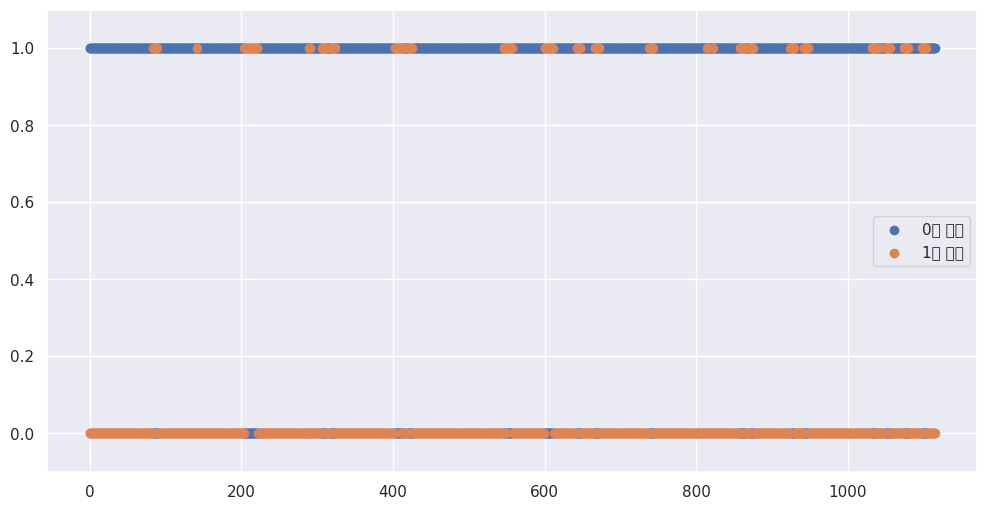

In [52]:
# 예측 결과에 대한 확률 값을 가져온다
proba_a1 = knn_grid_clf.best_estimator_.predict_proba(train_X)
# 0일 확률
a10 = proba_a1[:, 0]
# 1일 확률
a20 = proba_a1[:, 1]

plt.scatter(list(range(len(a10))), a10, label='0일 확률')
plt.scatter(list(range(len(a20))), a20, label='1일 확률')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

In [ ]:
10 / 0

In [ ]:
from sklearn.model_selection import train_test_split

train_X_sub, test_X, train_y_sub, test_y = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

# 그리고 나서 train_X_sub를 가지고 GridSearchCV 수행


In [53]:
# 최종 모델을 생성하고 전체 데이터를 학습 시킨다.
best_model = KNeighborsClassifier()
best_model.set_params(**knn_grid_clf.best_params_)
best_model.fit(train_X_sub, train_y_sub)
best_model

KNeighborsClassifier(n_neighbors=1)

In [ ]:
10/0

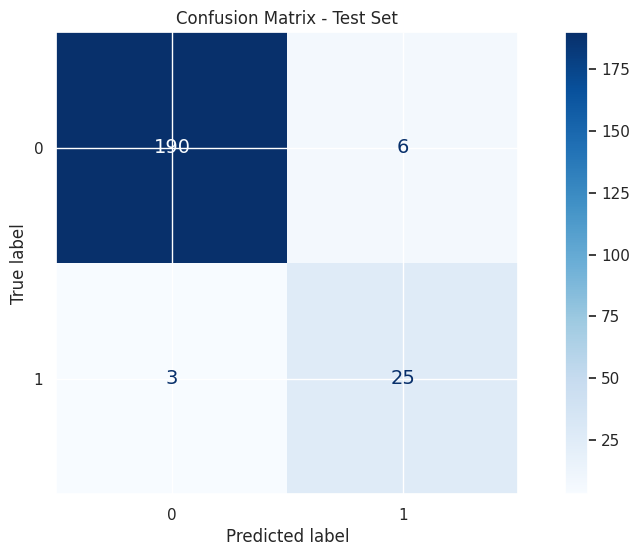

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. 최종 예측
y_pred = best_model.predict(test_X)

# 2. 혼동 행렬 계산
cm = confusion_matrix(test_y, y_pred)

# 3. 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')  # 'd'는 정수형 표시
plt.title("Confusion Matrix - Test Set")
plt.show()


In [55]:
# 학습 모델 등을 저장한다.
with open(best_model_path, 'wb') as fp :

    # 인코더들
    pickle.dump(인입횟수_ARS_R6M인코더, fp)
    pickle.dump(방문횟수_앱_R6M인코더, fp)
    pickle.dump(방문횟수_PC_R6M인코더, fp)
    pickle.dump(방문일수_PC_R6M인코더, fp)
    pickle.dump(거주시도명인코더, fp)
    pickle.dump(RV전환가능여부인코더, fp)
    pickle.dump(연령인코더, fp)
    pickle.dump(Life_Stage인코더, fp)
    pickle.dump(캠페인접촉건수_R12M인코더, fp)
    pickle.dump(이용메뉴건수_ARS_R6M인코더, fp)
    pickle.dump(대표청구서수령지구분코드인코더, fp)
    pickle.dump(청구서수령방법인코더, fp)
    pickle.dump(캠페인접촉일수_R12M인코더, fp)
    pickle.dump(할인건수_R3M인코더, fp)

    pickle.dump(best_model, fp)
    pickle.dump(scalerX, fp)

print('저장완료')

저장완료
